# Prototype: Run a Sobol sensitivity analysis with the model

In [25]:

import os
import importlib
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

from SALib.sample import sobol as sample_sobol
from SALib.analyze import sobol as analyse_sobol

import inframind_proteus.outbreak_dynamics
from inframind_proteus.outbreak_dynamics.sampling import sample_lhs

importlib.reload(inframind_proteus.outbreak_dynamics)
from inframind_proteus.outbreak_dynamics import (
    SimulationConfig, RenewalSimulator, SimulationOutput,
    LogisticRT, ConstantGammaGT, build_calibration_params_df,
    build_initial_infec_df
)


from inframind_proteus.outbreak_dynamics.utils import (
    load_yaml_dict, epiweek_to_date
)


In [31]:

# ===========

# --- Load configuration dict
# config_dict = load_yaml_dict(Path("../../configs/outbreak_dynamics_example.yaml"))
config_dict = load_yaml_dict(Path("../../configs/prototype_sobol_sensitivity.yaml"))
simulator = RenewalSimulator.from_config_dict(config_dict)
config = simulator.config

# --- Override parameters for this application
config.num_simulations = 2**16
config.sampling.method = "given"
config.mode = "projection"



# --- Define the SALib problem
problem = {
    'num_vars': len(config.sampling.param_ranges),
    'names': list(config.sampling.param_ranges.keys()),
    'bounds': list(config.sampling.param_ranges.values()),
}

# --- Sample parameters using SALib instead of the InfraMIND sampling function
# WARNING: This does not sample in non-linear scales (e.g. log)
sampled_params_df = pd.DataFrame(
    sample_sobol.sample(problem, config.num_simulations),
    columns=problem['names']
)
params_df = build_calibration_params_df(
    config.num_simulations, config.sampling,
    given_params=sampled_params_df
)
config.num_simulations = params_df.shape[0]

# --- Run the model with sampled parameters
initial_infec_df = build_initial_infec_df(
    config.num_simulations, simulator._gt_max_steps, config.temporal.step_dt,
    config.initial_infections
)
# --- Run simulations (calibration mode)
print(f"Running {config.num_simulations=}...")
model_results = simulator.run(
    params_df=params_df,
    initial_infec_df=initial_infec_df,
    # observations_sr=observations_sr,
)



/home/paulo_ventura/Inframind/IMDC2026/3rd_imdc_ifgw_inframind-proteus/src/inframind_proteus/outbreak_dynamics/sampling.py:356: UserWarning: Sampling method "'given'" produced 655360 samples, different from num_simulations=65536. This is expected for some methods, but you may have to update num_simulations to `params_df.shape[0]` for the new value after this function.
  warnings.warn(


Running config.num_simulations=655360...


Sensitivity of metric: log10_case_atk_rate
Sensitivity of metric: weeks_to_peak
Sensitivity of metric: atk_rate_rel_ci


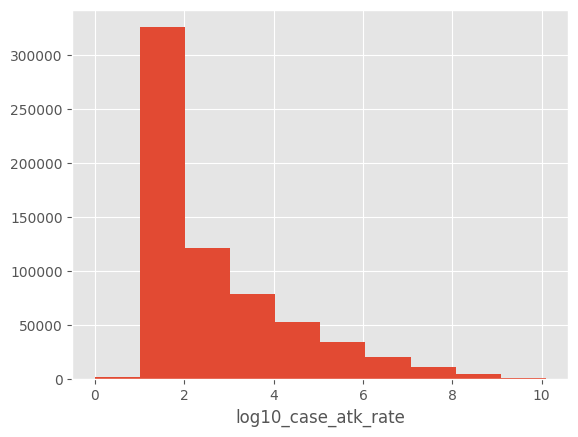

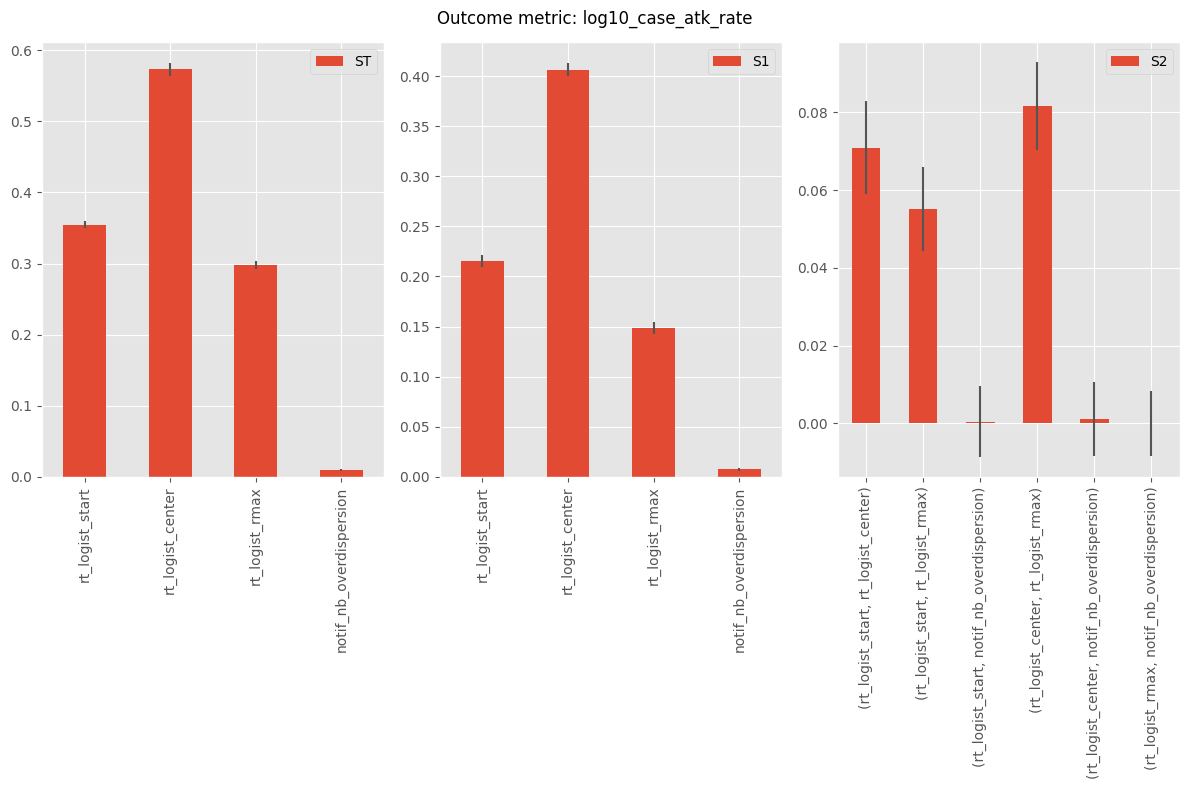

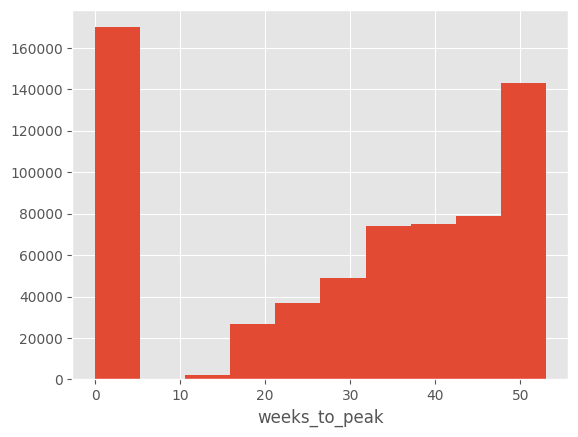

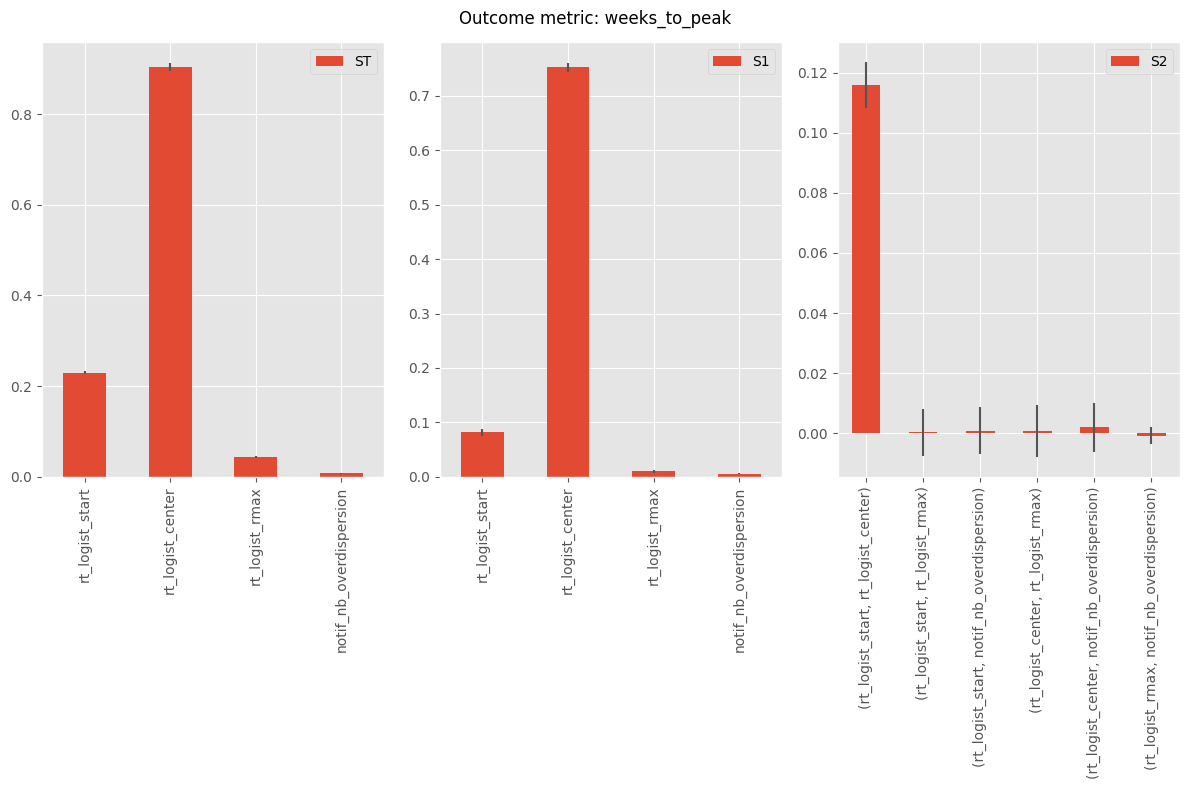

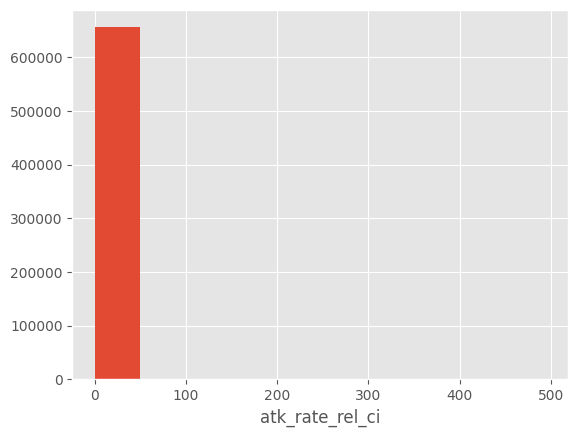

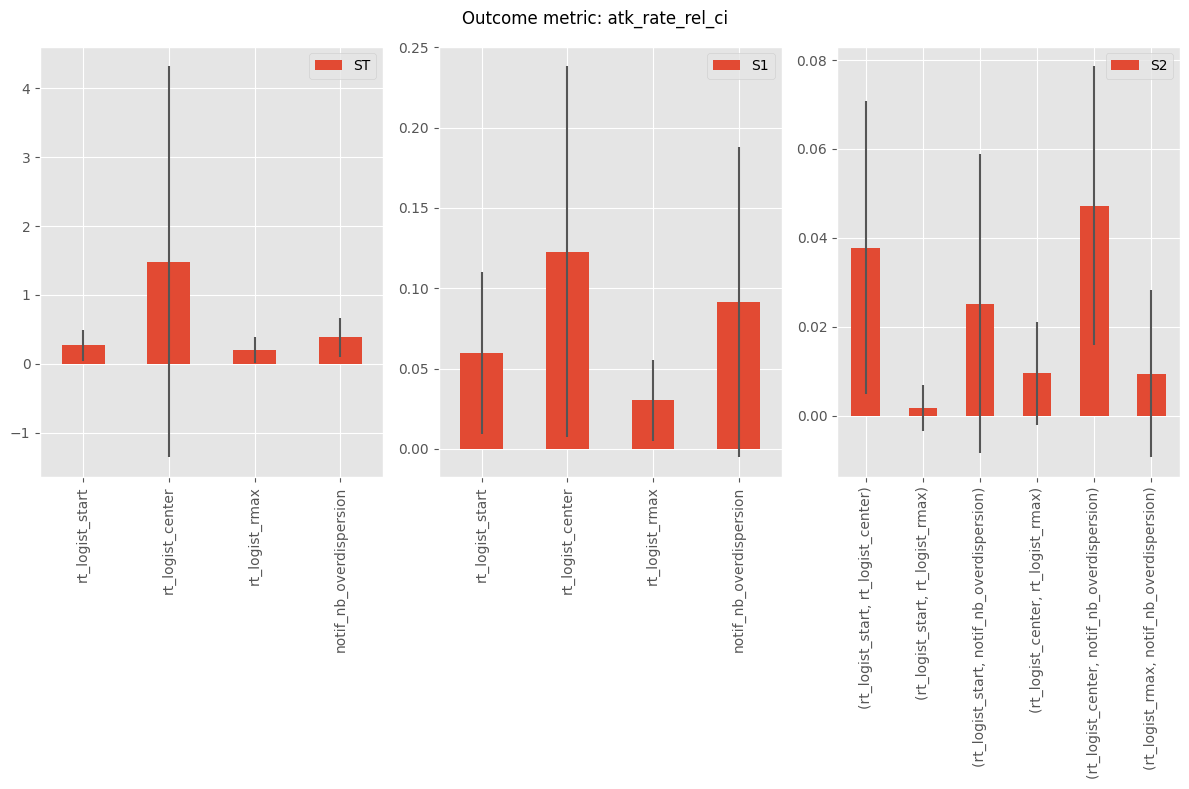

In [33]:

# --- Calculate summary metrics from the model results, to be used as outputs for the sensitivity analysis
model_metrics_df = pd.DataFrame({}, index=model_results.mean_cases_df.index)

model_median_cases_df = model_results.case_beam_df.xs(0.5, level="quantile")
#  ^^ Signature: df[i_simulation, time_step] = median prediction

# Features of median predictions
df: pd.DataFrame = model_median_cases_df
# model_metrics_df["case_atk_rate"] = df.sum(axis=1)
model_metrics_df["log10_case_atk_rate"] = np.log10(1 + df.sum(axis=1))
model_metrics_df["weeks_to_peak"] = (df.idxmax(axis=1) - df.columns.min()).dt.days // 7

# Features of the prediction intervals
df: pd.DataFrame = model_results.case_beam_df
# (Relative confidence interval of the attack rate)
model_50iqr_cases = df.xs(0.75, level="quantile") - df.xs(0.25, level="quantile")
_atk = model_median_cases_df.sum(axis=1)
model_metrics_df["atk_rate_rel_ci"] = np.where(
        _atk > 1,  # Regularize small denominators
        model_50iqr_cases.sum(axis=1) / model_median_cases_df.sum(axis=1),
        0.
)

# --- Run sobol sensitivity analysis
sobol_results = {}
for metric in model_metrics_df.columns:
    sobol_results[metric] = analyse_sobol.analyze(
        problem,
        model_metrics_df[metric].values,
        # print_to_console=True
    )

# --- Visualize results
pages_fpath = Path("../../.local/prototype_sobol_sensitivity/latest_results.pdf")
pages_fpath.parent.mkdir(parents=True, exist_ok=True)
with PdfPages(pages_fpath) as pdf_pages:
    with plt.rc_context():
        mpl.style.use("ggplot")
        # rc = mpl.sty
        # with
        for metric, sobol_result in sobol_results.items():
            print(f"Sensitivity of metric: {metric}\n===================")
            sobol_result: analyse_sobol.ResultDict

            # Outcome distributions
            fig, ax = plt.subplots()
            ax.hist(model_metrics_df[metric])
            ax.set_xlabel(metric)

            # Sobol SALib plots
            fig, axes = plt.subplots(ncols=3, figsize=(12, 8))
            sobol_result.plot(ax=axes)
            fig.suptitle(f"Outcome metric: {metric}")
            fig.tight_layout()

            # # Dataframe of sensitivity indices
            # for _df in sobol_result.to_df():
            #     display(_df)

            pdf_pages.savefig(fig)





np.float64(-844.4091236541225)

In [24]:
pd.Timestamp("2023-07-16") - pd.Timestamp("2023-10-01")

Timedelta('-77 days +00:00:00')